In [1]:
import numpy as np
from scipy.signal import find_peaks

from figures import *
from pipeline import *

In [2]:
# load in the spectra
from astropy.io.votable import parse
from astropy.table import Table

# to ignore "Angstroms" as an outdated label
import warnings
from astropy.units import UnitsWarning
warnings.filterwarnings("ignore", category=UnitsWarning)

data_root = "/datax/scratch/ktp/carmenes-lasers/test_data/"

lutyen_path = data_root + "carmenes_data_J07274+052_car-20160108T01h39m51s-sci-gtoc-vis_A.vot"
vot = parse(lutyen_path)

spec_ords, flux_ords, cont_ords, err_ords = [], [], [], []
n_tables = 1
for tab in vot.iter_tables():
    table = tab.to_table()

    if n_tables > 1:
        spec_ords.append(table[f'spectral-{n_tables:02d}'])
        flux_ords.append(table[f'flux-{n_tables:02d}'])
        cont_ords.append(table[f'cont_flux-{n_tables:02d}'])
        err_ords.append(table[f'err_flux-{n_tables:02d}'])
    else:
        spec_ords.append(table['spectral'])
        flux_ords.append(table['flux'])
        cont_ords.append(table['cont_flux'])
        err_ords.append(table['err_flux'])
    n_tables+=1

/home/ktp/miniconda3/envs/space-lasers/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


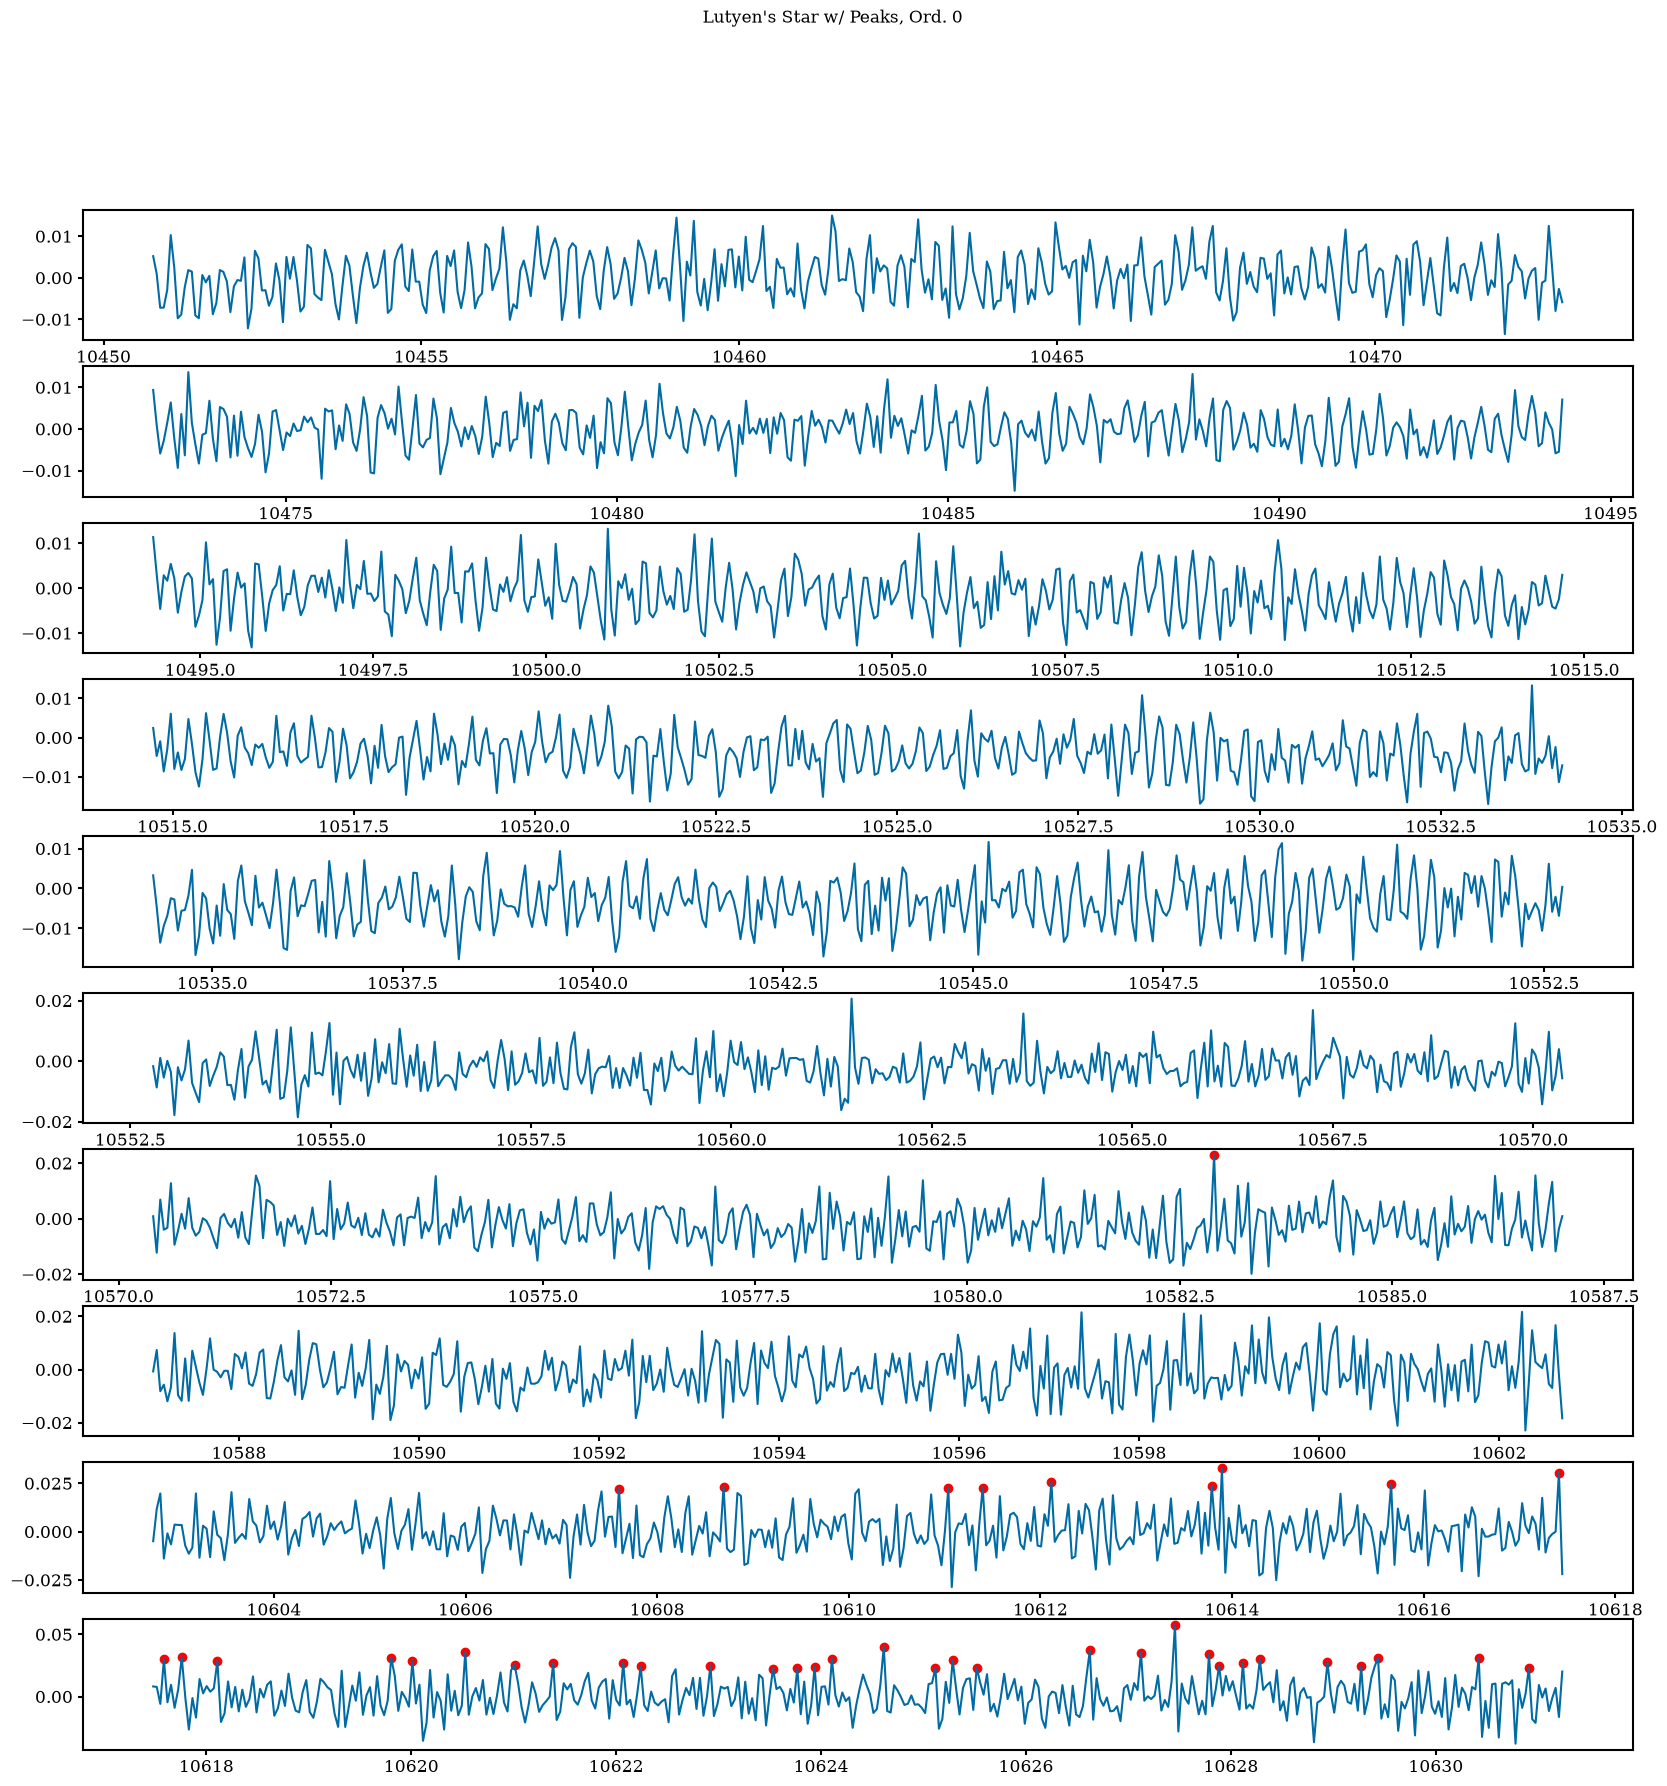

In [3]:
arb = 0
spec, flux = spec_ords[arb], flux_ords[arb]

n_sections = 10

max_diff = simple_threshold(flux, 3)

spec_sections, flux_sections = np.array_split(spec, n_sections), np.array_split(flux, n_sections)

spec_pk_sec, flx_pk_sec = [], []
for i, specsec in enumerate(spec_sections):   
    peaks, _ = find_peaks(flux_sections[i], max_diff)
    spec_pk_sec.append(specsec[peaks])
    flx_pk_sec.append(flux_sections[i][peaks])

fig, axs = plt.subplots(n_sections, figsize=(20,20))
plot_spectra_elike(fig, axs, spec, flux, n_sections, title=f"Lutyen's Star w/ Peaks, Ord. {arb}")
for i in range(n_sections):
    axs[i].scatter(spec_pk_sec[i], flx_pk_sec[i], color='red')

In [4]:
i = 1
fwhm_arr = full_width_half_max(spec_sections[i], 
                               flux_sections[i],
                               spec_pk_sec[i], 
                               flx_pk_sec[i],
                               0.01
                              )

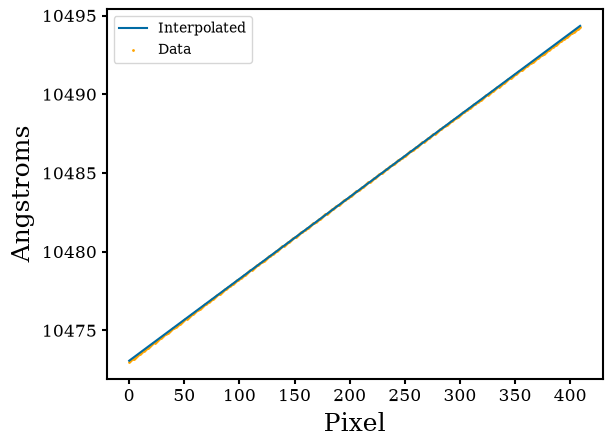

In [5]:
# let's assume fwhm of lsf is on the high end of 2.5-4px

# we need to find the relation btwn pixel and wavelength
pixels = np.arange(0, len(spec_sections[i]), 1)

fit_coeffs = np.polyfit(pixels, spec_sections[i], 1)
p = np.poly1d(fit_coeffs)

plt.plot(pixels, p(pixels), label="Interpolated")
plt.scatter(pixels, spec_sections[i], s=1, label="Data", color='orange')
plt.xlabel('Pixel')
plt.ylabel('Angstroms')
plt.legend()

In [6]:
# lets do this on a full order

arb = 3
spec, flux = spec_ords[arb], flux_ords[arb]

def spec_to_fwhms(spec, flux, sigma, max_diff=0.01, verbose=False):
    threshold = simple_threshold(flux, sigma) # get the std threshold

    peaks, _ = find_peaks(flux, threshold) # get peaks above threshold 
    spec_pks, flx_pks = spec[peaks], flux[peaks]
    
    fwhms = full_width_half_max(spec, flux, spec_pks, flx_pks, max_diff, verbose=verbose) # fwhm of peaks

    return fwhms

fwhms = spec_to_fwhms(spec, flux, 3)

# pixel - wavelength function to convert fwhm to pixels
pixels = np.arange(0, len(spec), 1)
fit_coeffs = np.polyfit(pixels, spec, 1)
spec_of_px = np.poly1d(fit_coeffs)

px_max = 4
px_min = 2.5

wl_max = spec_of_px(px_max) - spec_of_px(0)
wl_min = spec_of_px(px_min) - spec_of_px(0)

print(f'1 px = {spec_of_px(1) - spec_of_px(0)} ang')
print(f"wl range of fwhm of lsf {wl_min, wl_max}")

print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")
print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")

print(fwhms[:5])

1 px = 0.041975354850364965 ang
wl range of fwhm of lsf (np.float64(0.10493838712318393), np.float64(0.16790141939782188))
There are 19 peaks narrower than the max LSF
There are 19 peaks narrower than the max LSF
[0.10479194 0.10432797 0.1007456  0.06958718 0.06788971]


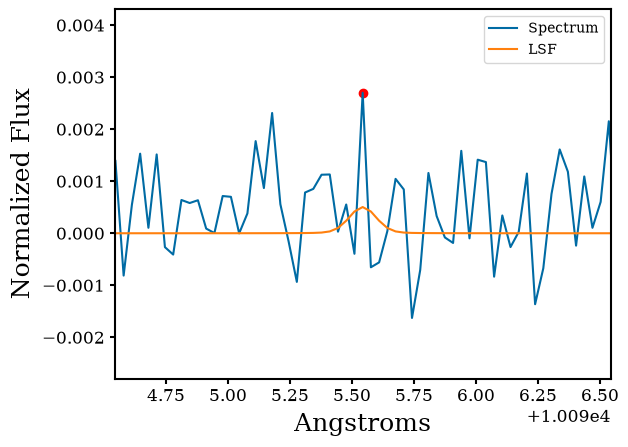

In [7]:
## take a peak, make a postage stamp of it and plot lsf on top
        
# take a peak
peak_idx = 5
buffer = 1

threshold = simple_threshold(flux, 3)
peaks, _ = find_peaks(flux, threshold)

lambda_c = spec[peaks][peak_idx]

plt.plot(spec, flux, label="Spectrum")
plt.plot(spec, lsf_per_wav(spec, np.array([lambda_c]), amplitude_L=flux[peaks][peak_idx]), label="LSF")
plt.scatter(lambda_c, flux[peaks][peak_idx], color='red')
plt.xlim(lambda_c - buffer, lambda_c + buffer)
plt.legend()
plt.xlabel('Angstroms')
plt.ylabel('Normalized Flux')
plt.show()